# 04 – Neural Network: Exercise Recognition

Dieses Notebook trainiert ein **Multilayer Perceptron (MLP)** auf den handgefertigten Features aus `03_Features` (ML_Module_Project).

---

## Warum MLP und nicht CNN/LSTM?

| Architektur | Wann sinnvoll | Hier? |
|---|---|---|
| **MLP** | Tabellarische Feature-Vektoren (mean, std, fft, …) | ✅ |
| CNN (1D) | Rohe Zeitreihenfenster direkt | ❌ (wäre Option 2, aber braucht PREPROC_DF) |
| LSTM/GRU | Sequenzen mit langer zeitl. Abhängigkeit | ❌ (Features sind bereits aggregiert) |

Da wir **aggregierte Features** (Mean, Std, FFT, Peak-Mittel) als Input haben und keinen rohen Zeitsignalstrom,  
ist ein MLP die natürlichste und effizienteste Wahl.

## Warum welche Activation Functions?

- **ReLU** in den Hidden Layers: Standard für tiefe Netze. Kein Vanishing-Gradient-Problem, rechnerisch günstig, konvergiert schnell.
- **Softmax** im Output Layer: Wir haben 35 Klassen (Mehrklassen-Klassifikation). Softmax wandelt die Rohausgaben in Wahrscheinlichkeiten um, die sich zu 1 summieren.  
  → In Keras wird Softmax explizit als letzte Aktivierung verwendet, zusammen mit `categorical_crossentropy` (oder `sparse_categorical_crossentropy`).
- **BatchNorm** nach jeder ReLU: Stabilisiert das Training, erlaubt höhere Lernraten.
- **Dropout** (p=0.3): Regularisierung gegen Overfitting – wichtig, da manche Klassen nur 2–130 Samples haben.

---

## Ordnerstruktur
```
ML_Module_Project/      ← bestehende Daten (read-only)
    features.pkl
    exercise_dict.pkl

NN_Module_Project/      ← dieses Projekt
    04_Neural_Network.ipynb   ← dieses File
    models/             ← wird automatisch erstellt
        best_model.keras
```

## 0 – Setup & Imports

In [1]:
# ── Zelle 1: Google Drive mounten ────────────────────────────────────────────
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Standard-Bibliotheken ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Scikit-learn (Preprocessing, Evaluation) ──────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ── TensorFlow / Keras ─────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f"TensorFlow Version : {tf.__version__}")
print(f"GPU verfügbar      : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Geräte             : {[d.name for d in tf.config.list_physical_devices()]}")

TensorFlow Version : 2.19.0
GPU verfügbar      : False
Geräte             : ['/physical_device:CPU:0']


In [3]:
from pathlib import Path
import os
print(Path.cwd())
print(os.listdir(Path.cwd()))

/content
['.config', 'drive', 'sample_data']


In [4]:
# ── Zelle 2: Pfade setzen & Dateien prüfen ───────────────────────────────────
# Drive-Ordner-ID aus deinem Link: 1y1en1SII7waBI4IjZagmqK48a_bauQRa
# Der Ordner liegt unter MyDrive – Pfad via ID direkt ansprechen

ML_PROJECT = Path('/content/drive/My Drive/NN_Project')

# Falls der obige Pfad nicht stimmt (Ordner in einem Unterordner),
# suchen wir automatisch anhand der Drive-ID:
if not ML_PROJECT.exists():
    import subprocess
    result = subprocess.run(
        ['find', '/content/drive', '-name', 'features.pkl'],
        capture_output=True, text=True
    )
    found = result.stdout.strip()
    if found:
        ML_PROJECT = Path(found).parent
        print(f"Gefunden unter: {ML_PROJECT}")
    else:
        print("Nicht gefunden – prüfe ob Drive korrekt gemountet ist")

MODEL_DIR = Path('/content/drive/My Drive/NN_Project/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Dateien prüfen ────────────────────────────────────────────────────────────
DATA_FILES = {
    'features'        : ML_PROJECT / 'features.pkl',
    'exercise_dict'   : ML_PROJECT / 'exercise_dict.pkl',
    'labeled_250ms'   : ML_PROJECT / '250MS_labeled.pkl',
    'resampled_250ms' : ML_PROJECT / '250MS_Resampled.pkl',
}

for name, path in DATA_FILES.items():
    assert path.exists(), f"{path.name} nicht gefunden unter {path}"
    print(f"  ✓ {path.name}")

print(f"\n✓ Alle {len(DATA_FILES)} Dateien gefunden.")
print(f"  ML-Daten : {ML_PROJECT}")
print(f"  Modelle  : {MODEL_DIR}")

  ✓ features.pkl
  ✓ exercise_dict.pkl
  ✓ 250MS_labeled.pkl
  ✓ 250MS_Resampled.pkl

✓ Alle 4 Dateien gefunden.
  ML-Daten : /content/drive/My Drive/NN_Project
  Modelle  : /content/drive/My Drive/NN_Project/models


## 1 – Daten laden & bereinigen

In [5]:
# ── Rohdaten einlesen ─────────────────────────────────────────────────────────
Feature_DF  = pd.read_pickle(DATA_FILES['features'])
EXERCISE_DF = pd.read_pickle(DATA_FILES['exercise_dict'])

# Mapping: Integer-Klasse → Übungsname
exercise_map = dict(zip(EXERCISE_DF['key'], EXERCISE_DF['value']))

print(f"Feature_DF Shape : {Feature_DF.shape}")
print(f"Klassen          : {sorted(Feature_DF['target'].dropna().unique().astype(int))}")
print(f"\nTarget-Verteilung:")
print(Feature_DF['target'].value_counts(dropna=False).head(10))

Feature_DF Shape : (8978, 103)
Klassen          : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(14), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]

Target-Verteilung:
target
0.0     4564
1.0     2167
7.0      255
2.0      251
24.0     130
11.0     127
17.0     111
3.0      107
21.0     107
26.0     102
Name: count, dtype: int64


In [6]:
# ── Nur gelabelte Fenster behalten (NaN-Target = kein Ground Truth) ───────────
df_labeled = Feature_DF.dropna(subset=['target']).copy()
df_labeled['target'] = df_labeled['target'].astype(int)

print(f"Gelabelte Fenster : {len(df_labeled)}")
print(f"Unlabeled (NaN)   : {len(Feature_DF) - len(df_labeled)}")

# ── Feature-Spalten = alle ausser target, target_name, datetime ───────────────
feature_cols = [c for c in df_labeled.columns if c not in ('target', 'target_name', 'datetime')]
print(f"\nAnzahl Features   : {len(feature_cols)}")
print(f"Beispiel-Features : {feature_cols[:6]}")

Gelabelte Fenster : 8937
Unlabeled (NaN)   : 41

Anzahl Features   : 100
Beispiel-Features : ['mean_HR_bpm', 'std_HR_bpm', 'fft_HR_bpm', 'mean_peak_HR_bpm', 'mean_val_HR_bpm', 'mean_ACC_z']


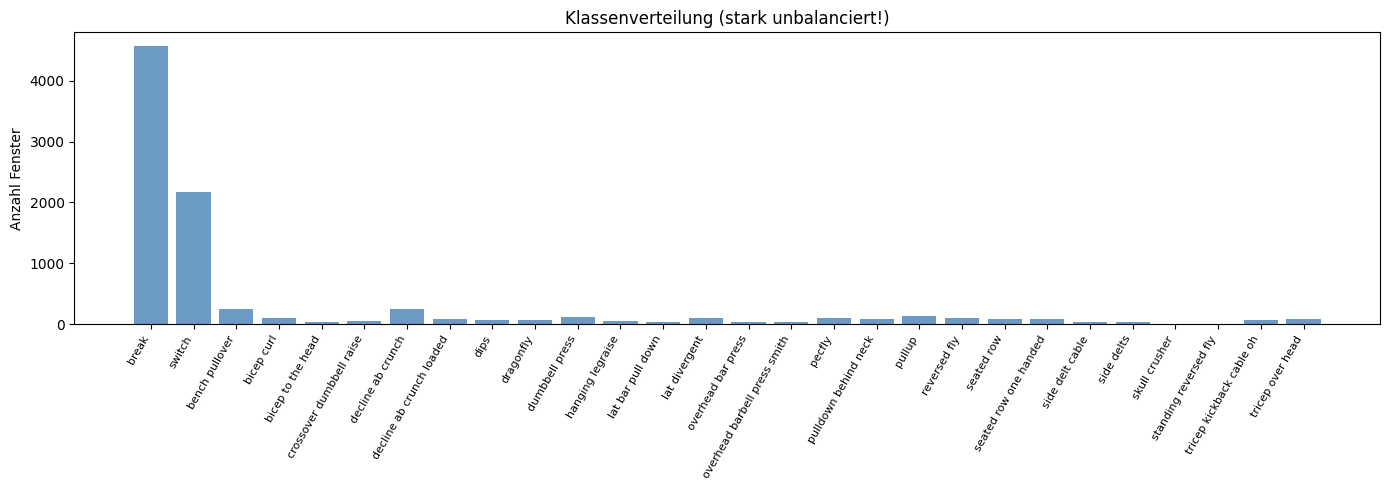

In [7]:
# ── Klassenverteilung visualisieren ───────────────────────────────────────────
# WICHTIG: Die Daten sind stark unbalanciert (break/switch >> Übungen)
# Das Netz würde sonst bias Richtung Mehrheitsklassen entwickeln.

counts = df_labeled['target'].value_counts().sort_index()
labels = [exercise_map.get(i, str(i)) for i in counts.index]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(counts)), counts.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Anzahl Fenster')
ax.set_title('Klassenverteilung (stark unbalanciert!)')
plt.tight_layout()
plt.show()

## 2 – Preprocessing: Skalierung & Train/Val/Test-Split

In [8]:
X = df_labeled[feature_cols].values.astype(np.float32)
y = df_labeled['target'].values

# ── Klassen mit weniger als 5 Samples entfernen ───────────────────────────────
# stratify braucht mindestens 2 Samples pro Klasse in JEDEM Split
# Bei 70/15/15 bedeutet das: mindestens ~5 Samples total pro Klasse
EXCLUDE_CLASSES = {0, 1}  # 0=break, 1=switch
min_samples = 5
class_counts = pd.Series(y).value_counts()
valid_classes = [c for c in class_counts[class_counts >= min_samples].index
                 if c not in EXCLUDE_CLASSES]
mask = pd.Series(y).isin(valid_classes).values

X = X[mask]
y = y[mask]

removed = class_counts[class_counts < min_samples]
print(f"Entfernte Klassen ({len(removed)}):")
for cls, cnt in removed.items():
    print(f"  {exercise_map.get(int(cls), str(cls)):30s} → {cnt} Sample(s)")

# ── Label-Encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
N_CLASSES = len(le.classes_)
print(f"\nAnzahl Klassen nach Encoding : {N_CLASSES}")

# ── 70% Train / 15% Val / 15% Test ───────────────────────────────────────────
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print(f"\nTrain : {X_train.shape[0]:>5} Samples")
print(f"Val   : {X_val.shape[0]:>5} Samples")
print(f"Test  : {X_test.shape[0]:>5} Samples")

Entfernte Klassen (2):
  skull crusher                  → 4 Sample(s)
  standing reversed fly          → 2 Sample(s)

Anzahl Klassen nach Encoding : 24

Train :  1540 Samples
Val   :   330 Samples
Test  :   330 Samples


In [9]:
# ── StandardScaler: Fit NUR auf Trainingsdaten! ───────────────────────────────
# Wichtig: val/test werden nur transformiert (kein re-fit)
# → verhindert Data Leakage

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# NaN-Werte auffüllen (können durch std=0 Features entstehen)
X_train_s = np.nan_to_num(X_train_s, nan=0.0)
X_val_s   = np.nan_to_num(X_val_s,   nan=0.0)
X_test_s  = np.nan_to_num(X_test_s,  nan=0.0)

N_FEATURES = X_train_s.shape[1]
print(f"Feature-Dimension : {N_FEATURES}")

Feature-Dimension : 100


## 3 – Klassenungleichgewicht behandeln

Zwei komplementäre Strategien:
1. **`class_weight`** im `model.fit()`: seltene Klassen werden stärker bestraft wenn falsch klassifiziert
2. **Oversampling** via `sample_weight` im `model.fit()`: seltenere Klassen werden im Mini-Batch stärker gewichtet

In Keras übergeben wir `class_weight` direkt an `model.fit()` – kein separater Sampler nötig.

In [10]:
# ── Klassen-Gewichte für den Loss ─────────────────────────────────────────────
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_CLASSES),
    y=y_train
)
# Keras erwartet class_weight als dict {Klasse: Gewicht}
class_weight_dict = {i: w for i, w in enumerate(class_weights_np)}
print("Class weights (erste 10):", class_weights_np[:10].round(2))

# ── Sample-Gewichte (Äquivalent zum WeightedRandomSampler in PyTorch) ─────────
sample_weights = class_weights_np[y_train]

Class weights (erste 10): [0.36 0.86 2.21 1.6  0.36 1.07 1.17 1.19 0.72 1.89]


## 4 – tf.data.Dataset Pipeline

In Keras/TensorFlow nutzen wir `tf.data.Dataset` anstelle von PyTorchs `DataLoader`.

In [11]:
# ── tf.data.Dataset Konfiguration ─────────────────────────────────────────────
BATCH_SIZE = 64

# Train-Dataset mit Sample-Gewichten (Äquivalent zum WeightedRandomSampler)
train_ds = tf.data.Dataset.from_tensor_slices((X_train_s, y_train, sample_weights))
train_ds = (train_ds
    .shuffle(buffer_size=len(X_train_s), reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)  # letzten unvollständigen Batch verwerfen (stabiler)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_s, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_s, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Train-Batches : {len(train_ds)}")
print(f"Val-Batches   : {len(val_ds)}")

Train-Batches : 24
Val-Batches   : 6


## 5 – Modell-Definition: MLP

### Architektur-Entscheidungen

```
Input (~100 Features)
    │
    ▼
Dense(256)  + BatchNorm + ReLU + Dropout(0.5)
    │
Dense(256)  + BatchNorm + ReLU + Dropout(0.4)
    │
Dense(128)  + BatchNorm + ReLU + Dropout(0.4)
    │
Dense(N_CLASSES, activation='softmax')   ← Wahrscheinlichkeiten
```

**ReLU** (Rectified Linear Unit) als Aktivierungsfunktion in den Hidden Layers:
- `max(0, x)` – einfach und effektiv
- Kein Vanishing-Gradient-Problem wie bei Sigmoid/Tanh
- De-facto Standard für MLPs und CNNs

**Softmax** wird in Keras explizit als letzte Aktivierung angegeben.
Kombiniert mit `sparse_categorical_crossentropy` als Loss-Funktion.

In [12]:
def build_exercise_mlp(n_features: int, n_classes: int,
                        hidden: list = [256, 256, 128]) -> keras.Model:
    """
    Multilayer Perceptron für Mehrklassen-Klassifikation von Fitness-Übungen.

    Aufbau: Dense → BatchNorm → ReLU → Dropout (x3), dann Output-Dense + Softmax
    """
    model = keras.Sequential(name='ExerciseMLP')
    model.add(layers.Input(shape=(n_features,)))

    dropouts = [0.5, 0.4]  # abnehmendes Dropout in tieferen Schichten

    for out_dim, drop in zip(hidden, dropouts):
        model.add(layers.Dense(out_dim, use_bias=True))     # Linear
        model.add(layers.BatchNormalization())               # stabilisiert Training
        model.add(layers.Activation('relu'))                 # Aktivierungsfunktion
        model.add(layers.Dropout(drop))                      # Regularisierung

    # Output: Softmax (explizit, da Keras kein internes Softmax im Loss hat)
    model.add(layers.Dense(n_classes, activation='softmax'))

    return model


# ── Modell initialisieren ─────────────────────────────────────────────────────
model = build_exercise_mlp(n_features=N_FEATURES, n_classes=N_CLASSES)
model.summary()

# Anzahl trainierbare Parameter
n_params = model.count_params()
print(f"\nTrainierbare Parameter: {n_params:,}")

Model: "ExerciseMLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,864 (390.09 KB)

 Trainable params: 98,840 (386.09 KB)

 Non-trainable params: 1,024 (4.00 KB)


Trainierbare Parameter: 99,864


## 6 – Training

In [13]:
# ── Loss & Optimizer ──────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',  # Integer-Labels (kein One-Hot nötig)
    metrics=['accuracy']
)

# ── Callbacks (entsprechen PyTorch-Logik) ─────────────────────────────────────
cb_list = [
    # ReduceLROnPlateau: LR halbieren wenn val_loss stagniert
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', mode='min', patience=10, factor=0.5, verbose=1
    ),
    # ModelCheckpoint: Bestes Modell speichern (wie torch.save bei best_val_loss)
    callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / 'best_model.keras'),
        monitor='val_loss', mode='min',
        save_best_only=True, verbose=1
    ),
    # EarlyStopping: Abbrechen wenn kein Fortschritt
    callbacks.EarlyStopping(
        monitor='val_loss', mode='min',
        patience=20, restore_best_weights=True, verbose=1
    ),
]

In [15]:
# ── Trainings-Loop ────────────────────────────────────────────────────────────
N_EPOCHS = 100

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=N_EPOCHS,
    # class_weight=class_weight_dict, # Entfernt, da sample_weights im train_ds sind
    callbacks=cb_list,
    verbose=1
)

print(f"\n✓ Bestes Modell gespeichert unter: {MODEL_DIR / 'best_model.keras'}")

Epoch 1/100
21/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1131 - loss: 3.2941
Epoch 1: val_loss improved from inf to 1.66880, saving model to /content/drive/My Drive/NN_Project/models/best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1339 - loss: 3.2136 - val_accuracy: 0.7485 - val_loss: 1.6688 - learning_rate: 0.0010
Epoch 2/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5497 - loss: 1.6968
Epoch 2: val_loss improved from 1.66880 to 1.06141, saving model to /content/drive/My Drive/NN_Project/models/best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5557 - loss: 1.6755 - val_accuracy: 0.8000 - val_loss: 1.0614 - learning_rate: 0.0010
Epoch 3/100
20/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6744 - loss: 1.2440
Epoch 3: val_loss improved from 1.06141 to 0.82000, saving model to /content/drive/My Drive/NN_Project/models/best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6761 - loss: 1.2272 - val_accuracy

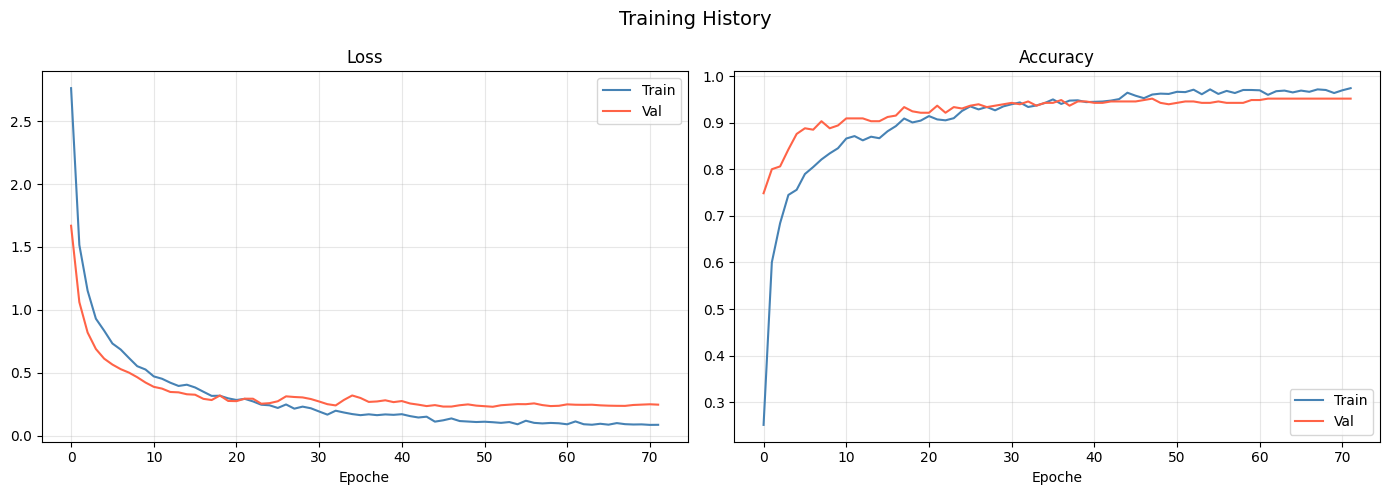

In [16]:
# ── Loss- und Accuracy-Kurven ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train', color='steelblue')
ax1.plot(history.history['val_loss'], label='Val',   color='tomato')
ax1.set_title('Loss')
ax1.set_xlabel('Epoche')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train', color='steelblue')
ax2.plot(history.history['val_accuracy'], label='Val',   color='tomato')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoche')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

## 7 – Evaluation auf dem Test-Set

In [17]:
# ── Bestes Modell laden ───────────────────────────────────────────────────────
model = keras.models.load_model(MODEL_DIR / 'best_model.keras')

# ── Predictions auf dem Test-Set ──────────────────────────────────────────────
probs      = model.predict(X_test_s, batch_size=BATCH_SIZE)
all_preds  = np.argmax(probs, axis=1)
all_labels = y_test

# ── Labels zurück-übersetzen (encoded → original IDs → Namen) ─────────────────
original_ids   = le.inverse_transform(np.arange(N_CLASSES))
class_names    = [exercise_map.get(int(i), str(i)) for i in original_ids]

# Nur Klassen die im Test-Set vorkommen (sonst Fehler in classification_report)
present = np.unique(all_labels)
present_names = [class_names[i] for i in present]

print("=" * 70)
print(classification_report(
    all_labels, all_preds,
    labels=present,
    target_names=present_names
))
print("=" * 70)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
                              precision    recall  f1-score   support

              bench pullover       0.92      0.97      0.95        37
                  bicep curl       1.00      0.94      0.97        16
           bicep to the head       1.00      1.00      1.00         7
    crossover dumbbell raise       1.00      1.00      1.00         9
           decline ab crunch       1.00      0.97      0.99        38
    decline ab crunch loaded       0.92      0.85      0.88        13
                        dips       0.92      1.00      0.96        11
                   dragonfly       1.00      0.92      0.96        12
              dumbbell press       0.89      0.84      0.86        19
            hanging legraise       1.00      1.00      1.00         7
           lat bar pull down       0.88      1.00      0.93         7
               lat divergent       0.89      1.00      0.94        16
          overhead bar press       1.00      1.00  

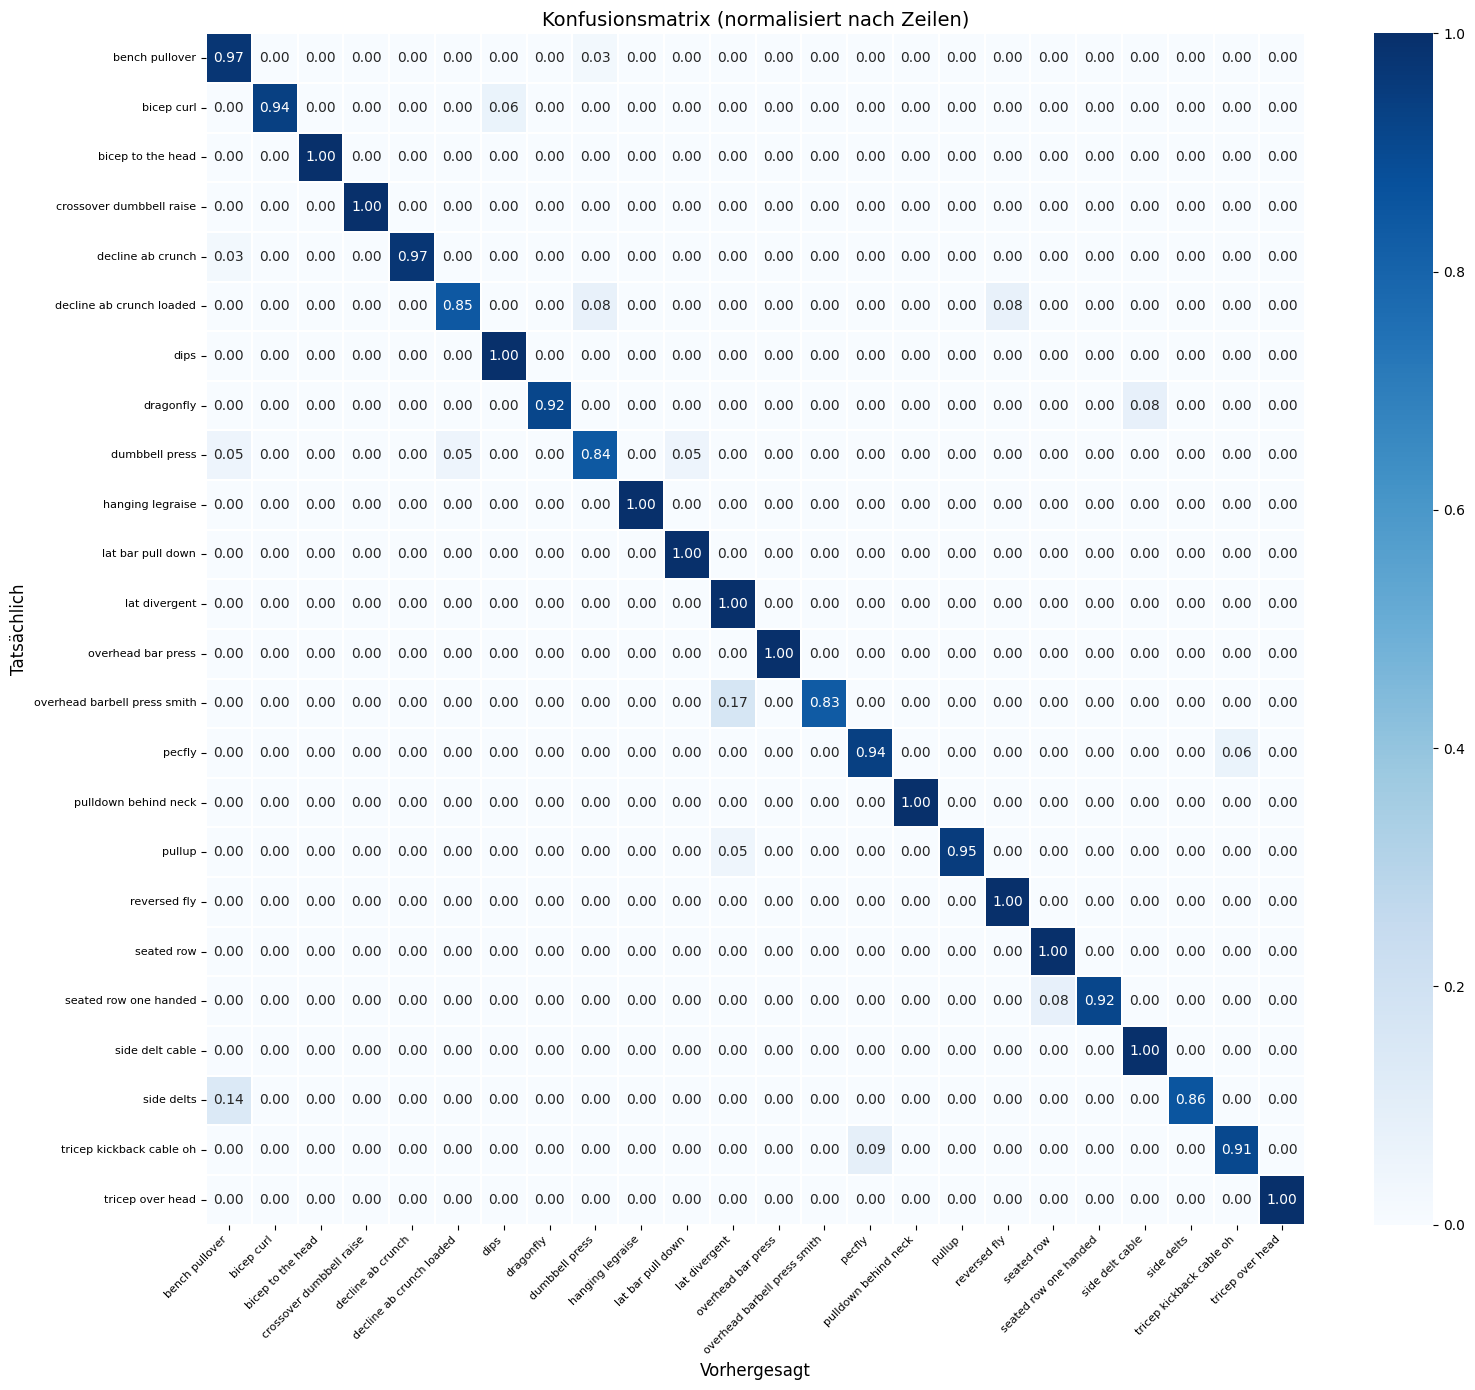

In [18]:
# ── Konfusionsmatrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds, labels=present, normalize='true')

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Vorhergesagt', fontsize=12)
ax.set_ylabel('Tatsächlich',  fontsize=12)
ax.set_title('Konfusionsmatrix (normalisiert nach Zeilen)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()

## 8 – Inference: Einzelne Vorhersage

In [19]:
def predict_exercise(feature_vector: np.ndarray, top_k: int = 3):
    """
    Vorhersage für einen einzelnen Feature-Vektor.

    Parameters:
        feature_vector : numpy-Array der Länge N_FEATURES (ungeskaliert, wie aus Feature_DF)
        top_k          : wie viele Top-Kandidaten anzeigen

    Returns:
        dict mit predicted_class, confidence, top_k_predictions
    """
    # Skalieren (gleicher Scaler wie beim Training!)
    x_scaled = scaler.transform(feature_vector.reshape(1, -1)).astype(np.float32)
    x_scaled = np.nan_to_num(x_scaled, nan=0.0)

    probs = model.predict(x_scaled, verbose=0)[0]

    top_indices = probs.argsort()[::-1][:top_k]
    top_classes = le.inverse_transform(top_indices)  # encoded → original ID

    return {
        'predicted_class' : exercise_map.get(int(top_classes[0]), 'unknown'),
        'confidence'      : float(probs[top_indices[0]]),
        'top_k'           : [
            {'class': exercise_map.get(int(c), str(c)), 'prob': float(probs[i])}
            for c, i in zip(top_classes, top_indices)
        ]
    }


# ── Beispiel: Erstes Sample aus dem Test-Set ──────────────────────────────────
sample_features = X_test[0]  # ungeskalierter Feature-Vektor
true_label      = exercise_map.get(int(le.inverse_transform([y_test[0]])[0]), 'unknown')

result = predict_exercise(sample_features, top_k=3)

print(f"Tatsächliche Klasse : {true_label}")
print(f"Vorhergesagt        : {result['predicted_class']} ({result['confidence']:.1%} Konfidenz)")
print(f"\nTop-3 Kandidaten:")
for entry in result['top_k']:
    print(f"  {entry['class']:35s}  {entry['prob']:.1%}")

Tatsächliche Klasse : pecfly
Vorhergesagt        : pecfly (100.0% Konfidenz)

Top-3 Kandidaten:
  pecfly                               100.0%
  bicep to the head                    0.0%
  seated row                           0.0%


## 9 – Modell & Scaler exportieren (für Deployment)

In [20]:
import pickle

# ── Scaler und Label-Encoder speichern ────────────────────────────────────────
# Wird für Inference auf neuen Daten benötigt
with open(MODEL_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(MODEL_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# ── Modell-Konfiguration speichern (zum späteren Laden) ───────────────────────
model_config = {
    'n_features' : N_FEATURES,
    'n_classes'  : N_CLASSES,
    'hidden'     : [128, 64],
    'feature_cols': feature_cols,
    'class_names': class_names
}
with open(MODEL_DIR / 'model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

print("✓ Gespeichert:")
for f in MODEL_DIR.iterdir():
    print(f"  {f.name}")

✓ Gespeichert:
  best_model.pt
  label_encoder.pkl
  scaler.pkl
  model_config.pkl
  best_model.keras


In [21]:
# ── Notebook als HTML exportieren → erst wenn Evaluation fertig ───────────────
import subprocess

# Sicherheitscheck: Export nur wenn Evaluation bereits gelaufen ist
assert 'all_preds' in dir(), "⚠️ Erst Zelle 7 (Evaluation) ausführen!"
assert 'result' in dir(),    "⚠️ Erst Zelle 8 (Inference) ausführen!"

NB_NAME     = '04_Neural_Network.ipynb'
NB_PATH     = Path('/content/drive/My Drive/NN_Project') / NB_NAME
OUTPUT_PATH = NB_PATH.with_suffix('.html')

# Notebook speichern bevor Export
import time
time.sleep(2)  # kurz warten damit Drive-Sync abgeschlossen ist

result_export = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html', str(NB_PATH), '--output', str(OUTPUT_PATH)],
    capture_output=True, text=True
)

if result_export.returncode == 0:
    print(f"✓ HTML gespeichert: {OUTPUT_PATH}")
else:
    print(f"Fehler: {result_export.stderr}")

✓ HTML gespeichert: /content/drive/My Drive/NN_Project/04_Neural_Network.html
